# Phase 3 — Building Real Models with `torch.nn`

Phase 2 ended with a glimpse: `nn.Linear` and `optim.SGD` replacing our hand-written weight
and hand-written update. This notebook opens that box up.

### What `torch.nn` is for

In Phase 2 we tracked one weight by hand. That worked because there was one. A real network
has millions, arranged in layers, and you need to be able to:

- create them all without writing a million lines
- hand every one of them to the optimizer
- save them to disk and load them back
- move them all onto a GPU with a single call

`nn.Module` is the container that does all of that. **Think of it as a box that keeps an
inventory of its own contents.** Put a layer inside, and the box automatically knows about
every dial that layer contains — no registration, no bookkeeping from you.

That inventory is the whole point. `model.parameters()` walks the box and hands the optimizer
everything adjustable. `model.to(device)` moves it all at once. `model.state_dict()` packages
it up for saving.

### The vocabulary

| Term | What it actually means |
|---|---|
| `nn.Parameter` | A tensor tagged *"this is a dial the optimizer may turn"* |
| `nn.Module` | The box that keeps an inventory of its dials and sub-boxes |
| `nn.Linear` | The standard layer: multiply by a weight matrix, add a bias |
| `nn.Sequential` | Several layers in a row, wrapped up as one model |
| loss function | Turns "how wrong were we?" into a single number |
| optimizer | Owns the rule for adjusting dials once the blame is known |
| `Dataset` / `DataLoader` | *How to fetch one item* / *a machine that serves shuffled trays* |
| `state_dict` | The model's learned numbers, as a plain name → tensor dictionary |

## What this notebook covers
```
nn.Parameter -> writing your own nn.Module -> ready-made layers & activations
    -> loss functions -> SGD vs Adam (measured, not assumed) -> the training loop
    -> train() vs eval() -> saving & loading -> Dataset & DataLoader
```
Everything the MNIST classifier in `phase3_project.ipynb` is built from.

## Section 1 — `nn.Parameter`: the "This One's Learnable" Tag

A plain tensor with `requires_grad=True` works perfectly well with autograd. We proved that
in Phase 2.

But `nn.Module` won't notice it exists.

`nn.Parameter` is a thin wrapper whose only job is to say *"I'm a dial this model should
learn."* When you attach one to a module, the module writes it into its inventory.

### The bug this prevents — and you will hit it

Write a custom model, forget `nn.Parameter`, and this happens:

```python
self.w = torch.tensor(0.0, requires_grad=True)   # ✗ works with autograd, invisible to the box
```

Now `model.parameters()` comes back **empty**. You hand that empty list to the optimizer,
which cheerfully accepts it, and training runs perfectly — with nothing being updated. The
loss just sits there, flat, for as many epochs as you care to run.

No error. No warning. Just a model that never learns.

```python
self.w = nn.Parameter(torch.tensor(0.0))         # ✓ in the inventory
```

**If your loss never moves, print `list(model.parameters())` first.** If it's empty, this is
your bug.

In [1]:
import torch
import torch.nn as nn

torch.manual_seed(42)

# A plain tensor with requires_grad=True works perfectly well with autograd --
# that's exactly what we used throughout Phase 2...
w_plain = torch.tensor(0.0, requires_grad=True)
print(f'plain tensor requires_grad : {w_plain.requires_grad}')

# ...but nn.Module won't NOTICE it. nn.Parameter is the tag that says
# "I'm a dial this model should learn", which is what .parameters() looks for.
#
# Forget this in a custom model and .parameters() comes back empty. The
# optimizer accepts the empty list without complaint, training runs, and the
# loss never moves. No error -- just nothing happening.
w_param = nn.Parameter(torch.tensor(0.0))
print(f'nn.Parameter requires_grad : {w_param.requires_grad}   <- True automatically')
print(f'type                       : {type(w_param)}')

plain tensor requires_grad : True
nn.Parameter requires_grad : True   <- True automatically
type                       : <class 'torch.nn.parameter.Parameter'>


## Section 2 — Writing Your Own Model

Every custom model in PyTorch has the same two-part shape:

```python
class MyModel(nn.Module):
    def __init__(self):          # PART 1: what pieces does this model have?
        super().__init__()       #         (this line first, always)
        self.layer = nn.Linear(3, 1)

    def forward(self, x):        # PART 2: how does data flow through them?
        return self.layer(x)
```

- **`__init__`** — build the pieces and attach them with `self.something = ...`
- **`forward`** — describe the path data takes from input to output

### Two rules that trip people up

**1. `super().__init__()` must come first.** That's the line that sets up the inventory. Skip
it and you get a confusing error the moment you attach anything.

**2. Attach with `self.`, or the box can't see it.** This is the same trap as Section 1, in a
different disguise:

```python
def __init__(self):
    super().__init__()
    layer = nn.Linear(3, 1)        # ✗ a local variable — vanishes when __init__ ends
    self.layer = nn.Linear(3, 1)   # ✓ attached — now it's in the inventory
```

### You never call `forward` yourself

Write `model(x)`, not `model.forward(x)`. They look equivalent and aren't — calling the model
directly runs PyTorch's hooks and mode-switching machinery around your `forward`. Calling
`forward` yourself skips all of it.

**Always `model(x)`.**

In [2]:
class ManualLinear(nn.Module):
    def __init__(self):
        super().__init__()
        # Two things matter on this line: nn.Parameter (the 'learnable' tag)
        # and self. (attaching it, so the box records it in its inventory).
        # Drop either one and this model silently refuses to learn.
        self.w = nn.Parameter(torch.tensor(0.0))
        self.b = nn.Parameter(torch.tensor(0.0))

    def forward(self, x):
        return self.w * x + self.b

model = ManualLinear()
print(f'model.w = {model.w.item()}, model.b = {model.b.item()}')

print('\nlist(model.parameters()):')
for p in model.parameters():
    print(f'  {p}  requires_grad={p.requires_grad}')

# Printing a module shows its structure -- handy for checking a model is
# actually built the way you think it is
print(f'\nmodel:\n{model}')

model.w = 0.0, model.b = 0.0

list(model.parameters()):
  Parameter containing:
tensor(0., requires_grad=True)  requires_grad=True
  Parameter containing:
tensor(0., requires_grad=True)  requires_grad=True

model:
ManualLinear()


## Section 3 — Ready-Made Layers, and Why Activations Matter

### `nn.Linear` — the workhorse

`nn.Linear(in_features, out_features)` is `w * x + b` grown up: it handles many inputs and
many outputs at once, as a matrix multiplication, with sensible starting values chosen for
you.

Read it as **"take this many numbers in, give me that many out."** `nn.Linear(784, 128)` takes
784 numbers (a flattened 28×28 image) and produces 128.

One thing to know now, because it looks like a bug later: the weight comes out shaped
`(out_features, in_features)` — **backwards from the arguments you passed**. That's because
the layer computes `x @ W.T`, and storing it this way makes that multiplication efficient.

### Activations — without them, depth is pointless

This is the part worth genuinely understanding.

Stack two `Linear` layers with nothing between them and you have... one `Linear` layer.
Multiplying by one matrix and then another is just multiplying by a third matrix. The maths
collapses. **A hundred stacked layers would still only be able to draw a straight line.**

An **activation function** is a small non-straight step placed between layers, and it's what
stops the collapse. With it, each layer genuinely adds capability, and the network can bend
to fit curves, edges, and shapes.

**ReLU** is the usual choice, and it's almost comically simple:

```
if the number is negative -> 0
otherwise                 -> leave it alone
```

That's the whole function. It's not smooth, it throws away all negative values, and it
outperformed the elegant S-shaped alternatives everyone used before it — largely because it's
so cheap to compute and its gradient doesn't fade away in deep stacks.

### `nn.Sequential` — layers in a row

When your model is just "this layer, then that one, then the next", `nn.Sequential` saves you
writing a class. Data flows straight through in the order you list them.

Reach for a full `nn.Module` class when the path isn't a simple line — branches, skip
connections, or anything conditional.

In [3]:
linear = nn.Linear(in_features=3, out_features=1)
print('=== nn.Linear(3, 1) ===')
# Note the weight comes out BACKWARDS from the arguments: (out, in), not (in, out).
# That's because the layer computes x @ W.T, and this layout makes that fast.
# It looks like a bug the first time you print it. It isn't.
print(f'weight shape: {linear.weight.shape}   <- (out_features, in_features)')
print(f'bias shape  : {linear.bias.shape}')
print(f'weight: {linear.weight}')
print(f'bias  : {linear.bias}')

x = torch.tensor([[1.0, 2.0, 3.0]])   # note the double brackets: (batch=1, features=3)
print(f'\ninput x shape : {x.shape}')
print(f'output shape  : {linear(x).shape}   <- (batch, out_features)')

# ── ACTIVATIONS — WHY DEPTH IS POINTLESS WITHOUT THEM ────────────────────────
# Stack two Linear layers with nothing in between and you have... one Linear
# layer. Multiplying by one matrix then another is just multiplying by a third.
# A hundred stacked layers could still only draw a straight line.
#
# An activation is a small non-straight step between layers that stops that
# collapse. ReLU is the usual pick, and the entire function is:
#     negative -> 0,  otherwise -> leave it alone
# That's it. Cheap to compute, and its gradient doesn't fade in deep stacks.
relu = nn.ReLU()
sample = torch.tensor([-2.0, -0.5, 0.0, 0.5, 2.0])
print(f'\nReLU({sample}) = {relu(sample)}   <- clamps negative values to 0')

# ── nn.SEQUENTIAL — LAYERS IN A ROW ──────────────────────────────────────────
# When the model is just 'this, then this, then this', Sequential saves you
# writing a class. Data flows straight through in the listed order.
# Use a full nn.Module class when the path branches or does anything conditional.
mlp = nn.Sequential(
    nn.Linear(4, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
)
print(f'\nmlp:\n{mlp}')

batch = torch.rand(5, 4)   # 5 samples, 4 features each -- the model handles the whole batch at once
print(f'\nmlp(batch of 5x4).shape: {mlp(batch).shape}   <- (5, 1)')

=== nn.Linear(3, 1) ===
weight shape: torch.Size([1, 3])   <- (out_features, in_features)
bias shape  : torch.Size([1])
weight: Parameter containing:
tensor([[ 0.4414,  0.4792, -0.1353]], requires_grad=True)
bias  : Parameter containing:
tensor([0.5304], requires_grad=True)

input x shape : torch.Size([1, 3])
output shape  : torch.Size([1, 1])   <- (batch, out_features)

ReLU(tensor([-2.0000, -0.5000,  0.0000,  0.5000,  2.0000])) = tensor([0.0000, 0.0000, 0.0000, 0.5000, 2.0000])   <- clamps negative values to 0

mlp:
Sequential(
  (0): Linear(in_features=4, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)

mlp(batch of 5x4).shape: torch.Size([5, 1])   <- (5, 1)


## Section 4 — Loss Functions: Scoring How Wrong You Are

A loss function turns "how did we do?" into **one number, where lower is better**. The whole
of training is the hunt for parameters that make it small.

Pick the one that matches your job:

### `nn.MSELoss` — for predicting a *number*

House prices, temperatures, someone's age. Takes the difference, squares it, averages.
Squaring means a miss of 10 hurts a hundred times as much as a miss of 1, so it leans hard on
eliminating big mistakes.

### `nn.CrossEntropyLoss` — for predicting a *category*

Which digit, which animal, spam or not. It rewards being confident **and right**, and
punishes being confident and **wrong** very harshly. Hedging your bets scores somewhere in
between.

### Two things about `CrossEntropyLoss` that catch everyone

**1. Feed it raw scores, not probabilities.** Your model's final layer should output plain
unbounded numbers — called **logits** — like `[2.0, 0.5, 0.1]`. Bigger means more confident.

It's tempting to add a `Softmax` at the end of your model to turn those into probabilities.
**Don't.** `CrossEntropyLoss` applies softmax internally. Add your own and it gets applied
twice, which flattens the differences your model is trying to express. It still trains, just
worse — with no error to tell you why. This is one of the most common silent bugs in PyTorch.

**2. Labels are plain integers.** For "this is class 2" you pass `2`, not `[0, 0, 1]`. No
one-hot encoding — PyTorch handles it.

The cell below shows the punishment in action: the same predictions scored against correct
labels, then against wrong ones.

In [4]:
# ── PREDICTING A NUMBER — MEAN SQUARED ERROR ─────────────────────────────────
# Difference, squared, averaged. Squaring means a miss of 10 hurts 100x as much
# as a miss of 1, so MSE leans hard on stamping out the big mistakes.
mse = nn.MSELoss()
pred = torch.tensor([2.5, 3.0, 5.0])
true = torch.tensor([3.0, 3.0, 4.0])
print(f'MSELoss: {mse(pred, true).item():.4f}')

# ── PREDICTING A CATEGORY — CROSS ENTROPY ────────────────────────────────────
# Rewards being confident AND right; punishes confident AND wrong very harshly.
#
# Two rules that catch everyone:
#   1. Feed it RAW scores (logits), never probabilities. It applies softmax
#      internally, so adding your own nn.Softmax applies it twice and quietly
#      trains a worse model with no error to warn you.
#   2. Labels are plain integers (2), not one-hot vectors ([0, 0, 1]).
ce = nn.CrossEntropyLoss()
# 'Logits' just means raw unbounded scores. Bigger = more confident. No softmax here.
logits = torch.tensor([[2.0, 0.5, 0.1],     # sample 1: leaning strongly toward class 0
                        [0.1, 0.2, 3.0]])   # sample 2: leaning strongly toward class 2
labels = torch.tensor([0, 2])                # true classes
print(f'CrossEntropyLoss (correct labels): {ce(logits, labels).item():.4f}')

# Now score the SAME confident predictions against the opposite labels.
# Being sure and wrong is the most expensive thing a classifier can do:
wrong_labels = torch.tensor([2, 0])
print(f'CrossEntropyLoss (wrong labels)  : {ce(logits, wrong_labels).item():.4f}   <- much higher')

MSELoss: 0.4167
CrossEntropyLoss (correct labels): 0.2132
CrossEntropyLoss (wrong labels)  : 2.6132   <- much higher


## Section 5 — Optimizers: SGD vs Adam

The optimizer owns the rule for adjusting parameters once autograd has worked out the blame.
It's the replacement for Phase 2's `with torch.no_grad(): w -= lr * w.grad`.

### `optim.SGD` — do exactly what the gradient says

```
param -= learning_rate * gradient
```

One fixed step size for everything. **Big gradient, big step.** Simple, predictable, and it
means the step size is at the mercy of however large the raw gradient happens to be.

### `optim.Adam` — adapt per parameter

Adam keeps running notes on each parameter's recent gradients and divides by them. The effect
is that **every step ends up roughly the size of your learning rate**, regardless of whether
the raw gradient was tiny or enormous.

It also carries **momentum**: like a ball rolling downhill, it builds speed in a consistent
direction and pushes through small bumps instead of getting stuck.

### Which one? Let's actually measure it

The received wisdom is "Adam is better, just use Adam". The cell below runs both on the same
tiny problem, same learning rate, same number of steps.

**SGD wins.** And that's not a mistake in the setup — it's the trade-off doing exactly what it
says. This problem starts with a big loss, so the raw gradient is large, and SGD's
unnormalised step covers ground fast. Adam deliberately caps its step near `lr`, so it takes
longer to arrive.

On a real, messy, high-dimensional problem — MNIST next door — that same capping is what
makes Adam reliable, because there the raw gradients vary wildly between parameters and SGD
has to be tuned carefully to cope.

**The lesson isn't "SGD is better" or "Adam is better".** It's that these are different
trade-offs, the popular default isn't automatically right for your problem, and measuring
takes thirty seconds.

In [5]:
import torch.optim as optim

# Same problem, same learning rate, same number of steps -- the only thing that
# changes between the two runs below is the optimizer. Let's measure rather than
# repeat the folklore that Adam always wins.
def train_tiny_model(optimizer_cls, lr, steps=30):
    torch.manual_seed(0)
    model = nn.Linear(1, 1)
    x = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
    y = torch.tensor([[2.0], [4.0], [6.0], [8.0]])
    optimizer = optimizer_cls(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for _ in range(steps):
        # the same five steps as always
        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()
    return loss.item()

sgd_loss = train_tiny_model(optim.SGD, lr=0.01)
adam_loss = train_tiny_model(optim.Adam, lr=0.01)

print('Final loss after 30 steps on the same problem, same learning rate:')
print(f'  SGD  : {sgd_loss:.5f}')
print(f'  Adam : {adam_loss:.5f}')
print('\nSGD actually wins here -- the raw gradient starts large (loss starts high),')
print('so its unnormalized step covers a lot of ground fast. Adam intentionally')
print('caps its step size near lr, so it needs more steps to catch up on a problem')
print('this simple. Neither optimizer is "just better" -- they make different')
print('trade-offs, and the right choice depends on the problem.')

Final loss after 30 steps on the same problem, same learning rate:
  SGD  : 0.16824
  Adam : 15.87001

SGD actually wins here -- the raw gradient starts large (loss starts high),
so its unnormalized step covers a lot of ground fast. Adam intentionally
caps its step size near lr, so it needs more steps to catch up on a problem
this simple. Neither optimizer is "just better" -- they make different
trade-offs, and the right choice depends on the problem.


## Section 6 — The Training Loop, As You'll Write It Forever

Same five steps as Phase 2, now with the built-in tools:

```python
optimizer.zero_grad()        # 1. clear the tally from last time
y_pred = model(x)            # 2. forward: predict
loss = loss_fn(y_pred, y)    # 3. how wrong?
loss.backward()              # 4. work out every parameter's blame
optimizer.step()             # 5. adjust every parameter
```

**This is the loop.** Every model you train from here on — the MNIST classifier next door,
the CNN in Phase 4, the fine-tuned ResNet in Phase 5 — is these five lines. What changes is
the model, the data and the loss; the shape never does.

Worth remembering about the order: `zero_grad()` can go at the top or the bottom, as long as
it happens between `backward()` calls. Top is more common, because it's harder to forget.

The example below reuses the same `y = 2x` problem, so you can compare it directly against
Phase 2's hand-written version and see that nothing mysterious got added — just packaging.

Epoch  10, Loss: 0.4992
Epoch  20, Loss: 0.6244
Epoch  30, Loss: 0.3739
Epoch  40, Loss: 0.1655
Epoch  50, Loss: 0.1264
Epoch  60, Loss: 0.0778
Epoch  70, Loss: 0.0420
Epoch  80, Loss: 0.0227
Epoch  90, Loss: 0.0120
Epoch 100, Loss: 0.0059

Learned: y = 1.940x + 0.180   (true relationship: y = 2x)


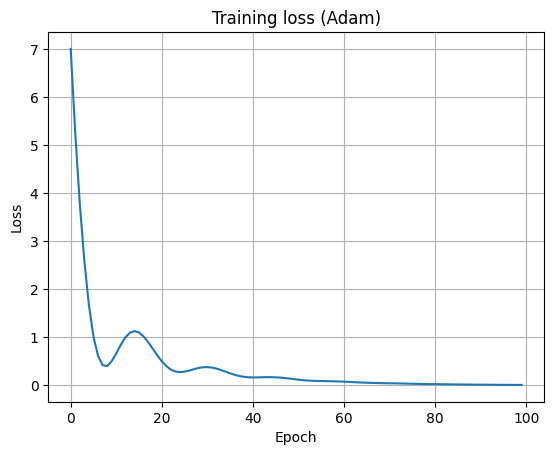

In [6]:
import matplotlib.pyplot as plt

class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()              # sets up the inventory -- always first
        # nn.Linear registers its own weight and bias as Parameters, so unlike
        # Section 2 we don't have to tag anything ourselves.
        self.linear = nn.Linear(1, 1)   # 1 number in -> 1 number out

    def forward(self, x):
        return self.linear(x)

x = torch.tensor([[1.], [2.], [3.], [4.]])
y = torch.tensor([[2.], [4.], [6.], [8.]])

torch.manual_seed(42)   # reseed here so this cell gives the same answer run alone
model = LinearModel()
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

loss_history = []
for epoch in range(100):
    # ===== THE FIVE STEPS. Every training loop you write is these. =====
    optimizer.zero_grad()          # 1. clear last step's tally
    y_pred = model(x)              # 2. forward -- predict
    loss = loss_fn(y_pred, y)      # 3. how wrong were we?
    loss.backward()                # 4. work out every parameter's blame
    optimizer.step()               # 5. adjust every parameter

    loss_history.append(loss.item())
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1:3d}, Loss: {loss.item():.4f}')

w = model.linear.weight.item()
b = model.linear.bias.item()
print(f'\nLearned: y = {w:.3f}x + {b:.3f}   (true relationship: y = 2x)')

plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss (Adam)')
plt.grid(True)
plt.show()

## Section 7 — `model.train()` vs `model.eval()`

Some layers deliberately behave **differently** while learning than while being used:

- **`nn.Dropout`** randomly switches off a fraction of the network during training. That
  sounds destructive; it's a proven anti-cheating measure. If the model can't rely on any
  particular neuron always being there, it can't lean too hard on one shortcut — so it learns
  something more robust. At prediction time you obviously want the *whole* network, so
  dropout switches itself off.
- **`nn.BatchNorm`** uses the statistics of the current batch while training, but a stored
  running average when evaluating — because a prediction shouldn't depend on which other
  items happened to be in the batch alongside it.

`model.train()` and `model.eval()` flip every such layer at once. **They don't train anything
or evaluate anything** — despite the names, they just set a mode flag.

### Why forgetting this is nasty

Forget `model.eval()` before testing, and dropout stays on. Your model gives a *different
answer every time you ask it the same question*, and your accuracy is worse than it should
be — for a reason nothing on screen will point you to.

**The habit:** `model.train()` before the training loop, `model.eval()` before testing, and
`torch.no_grad()` alongside the eval. Neither model here uses dropout yet, so the cell below
adds one just to make the difference visible.

In [7]:
torch.manual_seed(1)
dropout_demo = nn.Sequential(nn.Linear(4, 4), nn.Dropout(p=0.5))
sample = torch.ones(1, 4)

# train() mode: dropout switches off a random ~50% of values each time.
# It's an anti-cheating measure -- if the model can't rely on any particular
# neuron being there, it can't lean too hard on one shortcut.
dropout_demo.train()
print('train() mode, 3 runs (randomness expected):')
for _ in range(3):
    print(dropout_demo(sample))

# eval() mode: dropout switches itself off entirely, so the same input always
# gives the same answer. Forget this line before testing and your accuracy is
# quietly worse, with nothing on screen to tell you why.
dropout_demo.eval()
print('\neval() mode, 3 runs (should be identical):')
for _ in range(3):
    print(dropout_demo(sample))

train() mode, 3 runs (randomness expected):
tensor([[ 0.0000, -0.0427,  0.0000,  0.1238]], grad_fn=<MulBackward0>)
tensor([[ 0.4943, -0.0427,  0.0000,  0.1238]], grad_fn=<MulBackward0>)
tensor([[0., -0., 0., 0.]], grad_fn=<MulBackward0>)

eval() mode, 3 runs (should be identical):
tensor([[ 0.2472, -0.0213,  0.6087,  0.0619]], grad_fn=<AddmmBackward0>)
tensor([[ 0.2472, -0.0213,  0.6087,  0.0619]], grad_fn=<AddmmBackward0>)
tensor([[ 0.2472, -0.0213,  0.6087,  0.0619]], grad_fn=<AddmmBackward0>)


## Section 8 — Saving and Loading a Trained Model

A model's learned numbers live in its **`state_dict()`** — an ordinary dictionary mapping
`"linear.weight"` to the tensor holding it. Save that dictionary and you've saved everything
your model learned.

### Save the numbers, not the object

You *can* pickle the whole model object with `torch.save(model, path)`. Don't. It hard-codes
the file path of the class that defined it, so renaming your file or reorganising your project
breaks every model you ever saved.

The recommended pattern is two lines and never breaks:

```python
torch.save(model.state_dict(), 'model.pth')                 # save just the numbers

model = LinearModel()                                        # rebuild the same architecture
model.load_state_dict(torch.load('model.pth'))               # pour the numbers in
model.eval()                                                 # switch to prediction mode
```

**You have to rebuild the architecture yourself first.** The file holds numbers, not
structure — it has no idea what shape of model they belong to. If your class doesn't match
what was saved, loading fails with a mismatched-keys error that tells you exactly which layers
disagree.

And `.eval()` after loading, every time. You're about to make predictions, not train.

In [8]:
import os

# Save the NUMBERS, not the object. torch.save(model, path) also works but
# hard-codes where your class was defined, so renaming a file later breaks
# every model you ever saved.
save_path = 'linear_model.pth'
torch.save(model.state_dict(), save_path)
print(f'Saved state_dict to {save_path}')
print(f'state_dict keys: {list(model.state_dict().keys())}')

# ── LOADING — BUILD THE SAME ARCHITECTURE FIRST, THEN POUR THE NUMBERS IN ────
# The file holds numbers, not structure -- it has no idea what shape of model
# they belong to. So you rebuild the class yourself, then load into it.
# If the architecture doesn't match, you get an error naming the layers that disagree.
loaded_model = LinearModel()
print(f'\nBefore loading, fresh model weight: {loaded_model.linear.weight.item():.4f}  (random init)')

loaded_model.load_state_dict(torch.load(save_path))
loaded_model.eval()   # about to predict, not train -- do this every time after loading
print(f'After loading, weight: {loaded_model.linear.weight.item():.4f}  (matches trained model: {w:.4f})')

os.remove(save_path)  # clean up -- this notebook is just a demo

Saved state_dict to linear_model.pth
state_dict keys: ['linear.weight', 'linear.bias']

Before loading, fresh model weight: -0.5268  (random init)
After loading, weight: 1.9397  (matches trained model: 1.9397)


## Section 9 — `Dataset` and `DataLoader`: Feeding Data In

So far we've thrown all four training samples in at once. That works for four. It does not
work for 60,000 MNIST images, which won't fit in memory together.

The answer is **mini-batches**: process 32 or 64 samples at a time. Three benefits at once —
it fits in memory, the GPU stays busy, and the slight randomness of each batch actually helps
the model generalise.

PyTorch splits this into two jobs:

### `Dataset` — "how do I get one item?"

Two methods, that's all:
- **`__len__`** → how many items are there?
- **`__getitem__(i)`** → give me item number `i`, as `(input, label)`

Notably, it doesn't have to hold the data in memory. `__getitem__` can read a file from disk
on demand, which is how people train on datasets far bigger than their RAM.

### `DataLoader` — "serve them to me in trays"

Wrap a `Dataset` in a `DataLoader` and it handles the rest:
- **`batch_size=32`** → stack 32 items into one batch
- **`shuffle=True`** → different order every epoch, so the model can't memorise the sequence
- **`num_workers=4`** → load in background processes while the GPU works on the last batch

Then you just loop over it, and each turn hands you a ready-made batch.

**Shuffle the training data; don't bother shuffling the test data.** Shuffling exists to stop
the model learning the order, which only matters while it's learning.

### `TensorDataset` — the shortcut

If your data is already tensors, `TensorDataset(x, y)` skips the class entirely. Write your
own `Dataset` when you need to load from disk or apply transforms per item.

In [9]:
from torch.utils.data import Dataset, DataLoader, TensorDataset

# ── A DATASET ANSWERS ONE QUESTION: 'HOW DO I GET ITEM i?' ───────────────────
# Only two methods needed. Note it doesn't have to hold everything in memory --
# __getitem__ could read a file from disk instead, which is how people train on
# datasets far larger than their RAM.
class SquareDataset(Dataset):
    def __init__(self, n):
        self.x = torch.arange(1, n + 1, dtype=torch.float32).unsqueeze(1)
        self.y = self.x ** 2

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

dataset = SquareDataset(10)
print(f'len(dataset): {len(dataset)}')
print(f'dataset[0]  : {dataset[0]}')

# The DataLoader turns single items into shuffled trays of 4.
# shuffle=True gives a different order every epoch, so the model learns the
# data rather than the running order. Shuffle training data, not test data.
loader = DataLoader(dataset, batch_size=4, shuffle=True)
print('\n=== Batches from DataLoader (shuffle=True) ===')
for batch_idx, (xb, yb) in enumerate(loader):
    print(f'batch {batch_idx}: x={xb.view(-1).tolist()}  y={yb.view(-1).tolist()}')

# ── TensorDataset — THE SHORTCUT ─────────────────────────────────────────────
# When your data is already sitting in tensors, this skips the class entirely.
# Write your own Dataset when you need to load from disk or transform per item.
quick_dataset = TensorDataset(dataset.x, dataset.y)
quick_loader = DataLoader(quick_dataset, batch_size=4, shuffle=False)
print('\n=== Same idea via TensorDataset (shuffle=False) ===')
for batch_idx, (xb, yb) in enumerate(quick_loader):
    print(f'batch {batch_idx}: x={xb.view(-1).tolist()}')

len(dataset): 10
dataset[0]  : (tensor([1.]), tensor([1.]))

=== Batches from DataLoader (shuffle=True) ===
batch 0: x=[9.0, 3.0, 2.0, 6.0]  y=[81.0, 9.0, 4.0, 36.0]
batch 1: x=[1.0, 7.0, 10.0, 4.0]  y=[1.0, 49.0, 100.0, 16.0]
batch 2: x=[8.0, 5.0]  y=[64.0, 25.0]

=== Same idea via TensorDataset (shuffle=False) ===
batch 0: x=[1.0, 2.0, 3.0, 4.0]
batch 1: x=[5.0, 6.0, 7.0, 8.0]
batch 2: x=[9.0, 10.0]


## Phase 3 Summary

### Cheat sheet
```
Parameters & modules:
  nn.Parameter(tensor)     -> tags a tensor as "learnable"; nn.Module then tracks it
  class M(nn.Module):
      def __init__(self):
          super().__init__()          <- FIRST line, always
          self.layer = nn.Linear(...)  <- attach with self. or it's invisible
      def forward(self, x): return self.layer(x)
  model(x)                  -> runs forward (never call model.forward(x) yourself)
  model.parameters()         -> everything learnable, submodules included

Layers:
  nn.Linear(in_features, out_features)   -> the workhorse
  nn.Sequential(layer, activation, ...)   -> a straight-line stack
  nn.ReLU()                                -> negatives to 0; without it, depth is pointless

Loss functions:
  nn.MSELoss()            -> predicting a NUMBER
  nn.CrossEntropyLoss()   -> predicting a CATEGORY
                             feed it RAW logits (never add your own Softmax)
                             labels are plain ints (2), not one-hot ([0,0,1])

Optimizers:
  optim.SGD(model.parameters(), lr=)    -> step follows the raw gradient
  optim.Adam(model.parameters(), lr=)   -> per-parameter, roughly lr-sized steps + momentum
                                            (a trade-off, not a free win -- measure it)

The training loop (the shape never changes):
  optimizer.zero_grad() -> model(x) -> loss_fn(pred, y) -> loss.backward() -> optimizer.step()

Modes:
  model.train()   -> before training   (dropout on, batchnorm uses this batch)
  model.eval()    -> before testing    (dropout off, batchnorm uses running averages)

Saving & loading:
  torch.save(model.state_dict(), 'm.pth')
  model = MyModel(); model.load_state_dict(torch.load('m.pth')); model.eval()
  (rebuild the architecture yourself -- the file holds numbers, not structure)

Data:
  class D(Dataset): __len__, __getitem__     -> how to fetch ONE item
  DataLoader(dataset, batch_size=, shuffle=)  -> serves shuffled batches
  TensorDataset(x, y)                          -> shortcut when data is already tensors
```

### The five things worth memorising

1. **`nn.Parameter` + `self.` or the model can't see it.** Empty `parameters()` = a loss that
   never moves, with no error.
2. **Activations are what make depth worth having.** Without them, any stack of Linear layers
   collapses into one.
3. **Never add `Softmax` before `CrossEntropyLoss`.** It's already in there. Silent bug.
4. **`model.eval()` before you test**, or dropout gives you a different answer every run.
5. **The five-line loop never changes.** Only the model, data and loss do.

### Test yourself before moving on

1. Build an `nn.Sequential` that takes 10 features → 32 → 16 → 3 classes, with ReLU between
   layers. How many `Linear` layers, and how many activations?
2. In `ManualLinear`, swap `nn.Parameter(...)` for a plain `torch.tensor(..., requires_grad=True)`.
   What does `model.parameters()` return now? What happens if you train it?
3. Why does `nn.Linear(3, 1).weight` have shape `(1, 3)` rather than `(3, 1)`?
4. You load a saved model and predictions differ slightly on every run. What did you forget?

### Up next — the MNIST project
`phase3_project.ipynb` puts all nine sections together: real images, a real `DataLoader`, a
real network, and honest accuracy measured on data the model has never seen.